# Isochronous topology optimization on HDiv-MMM: density adjoint, constrained design loop, exact-void verification

Result-bearing showcase for `radia.isochronous_topopt` (2026-07-28).  Design record:
[`TOPOLOGY_OPTIMIZATION_ISOCHRONOUS.md`](TOPOLOGY_OPTIMIZATION_ISOCHRONOUS.md); validation lane with golden
bands: `validation_test/isochronous_topopt/`; fast structural locks: `tests/test_isochronous_topopt.py`.

**Method.** The HDiv-MMM system is affine in the per-element design variable $s_e = 1/\chi_e$:

$$A(s)\,m = \Big(\textstyle\sum_e s_e M^{(e)} + N\Big) m = P\,h_{\rm ext},\qquad N = B^{\sf T} G B\ \text{(geometry only, built once)},$$

so $\partial A/\partial s_e = M^{(e)}$ exactly, and the self-adjoint operator serves state and adjoint with one
factorization.  A field functional $J = c^{\sf T} F m$ (weighted point evaluations, e.g. orbit-quadrature
$\partial B_z/\partial r$ for the focusing integral $gL$) gets its adjoint load $F^{\sf T} c$ by **kernel
reciprocity** -- the mass projection of the analytic H field of a point-dipole array at the orbit points; the
dense magnetization-to-field matrix is never formed.  All element sensitivities come from ONE element-wise
integral:

$$A\,\lambda = F^{\sf T} c,\qquad \frac{dJ}{ds_e} = -\lambda^{\sf T} M^{(e)} m = -\int_e \lambda\cdot m\,dV.$$


## 1. Adjoint gate: gradient vs central finite differences, reciprocity vs the independent C++ evaluator

Unit ball, log-uniform $s\in[10^{-2},1]$, six orbit points outside the body with a generic weighted
$\partial B_z/\partial x$ functional realized as $\pm$ dipole pairs.


In [1]:
import time
from math import pi

import numpy as np
from netgen.occ import Cylinder, HalfSpace, OCCGeometry, Pnt, Sphere, Vec, Z
from ngsolve import HDiv, InnerProduct, Mesh, SetNumThreads, TaskManager

from radia.isochronous_topopt import (
    MU0, DensityAdjointVIM, HelmholtzFilter, demag_field_from_solution,
    density_to_s, field_functional_load, gradient_pair_points,
    optimize_density, orbit_arc_points, uniform_field_load,
    verify_design_iron_only)

SetNumThreads(4)
summary = {}
with TaskManager():
    ball = Mesh(OCCGeometry(Sphere(Pnt(0, 0, 0), 1.0)).GenerateMesh(maxh=0.35))
    prob = DensityAdjointVIM(HDiv(ball, order=1), eps=1e-7)
    rng = np.random.default_rng(1234)
    s0 = np.exp(rng.uniform(np.log(1e-2), 0.0, prob.n_el))
    orbit, _ = orbit_arc_points(1.6, 0.3, 6)
    w = np.array([1.0, -0.7, 1.3, 0.5, -1.1, 0.9])
    dp, dw = gradient_pair_points(orbit, w, delta=0.1, axis=0)
    f_state = uniform_field_load(prob.fes, (0, 0, 1.0))
    f_adj = field_functional_load(prob.fes, dp, dw, axis=2, scale=MU0, bonus_intorder=10)
    base = prob.objective_and_gradient(s0, f_state, f_adj, tol=1e-12)
    d = np.random.default_rng(99).standard_normal(prob.n_el)
    ds, h = s0 * d, 1e-5
    gp, _ = prob.solve(s0 + h * ds, f_state, tol=1e-12)
    gm, _ = prob.solve(s0 - h * ds, f_state, tol=1e-12)
    fd = (InnerProduct(f_adj.vec, gp.vec) - InnerProduct(f_adj.vec, gm.vec)) / (2 * h)
    pred = float(base.gradient @ ds)
    H_d = demag_field_from_solution(prob.demag, base.gfM, dp)
J_indep = float(MU0 * np.dot(dw, H_d[:, 2]))
summary['adjoint_gate'] = dict(
    ne=ball.ne, ndof=prob.fes.ndof,
    directional_fd_rel=abs(fd - pred) / abs(pred),
    reciprocity_rel=abs(base.objective - J_indep) / abs(J_indep))
print(f"ne={ball.ne}  ndof={prob.fes.ndof}")
print(f"directional adjoint vs FD : rel = {summary['adjoint_gate']['directional_fd_rel']:.3e}")
print(f"reciprocity vs C++ charges: rel = {summary['adjoint_gate']['reciprocity_rel']:.3e}")


ne=270  ndof=1977
directional adjoint vs FD : rel = 1.784e-07
reciprocity vs C++ charges: rel = 1.099e-10


## 2. Constrained design loop (trust-region SLP)

Sector-pole surrogate: annular-sector iron above the midplane, arc-orbit radial $\partial B_z/\partial r$
objective near the outer edge (MAXIMIZED), two mean-$B_z$ isochronism-surrogate constraints held in absolute
0.5 % bands (the $\pm$ row pairs enter `radia.topology_optimization.solve_lp_update`'s `A_ub` slot,
normalized to O(1) -- Tesla-scale rows sit below HiGHS's absolute feasibility tolerance), a 50 % iron volume
budget, and a Helmholtz density filter.  Acceptance keeps the ascent monotone and the violations bounded by
$1.25\times$band with no ratchet path.


In [2]:
def make_sector_mesh(R1=0.05, R2=0.15, angle_deg=60.0, z0=0.02, thick=0.03, maxh=0.02):
    from math import cos, sin
    ang = angle_deg * pi / 180.0
    ring = (Cylinder(Pnt(0, 0, z0), Z, r=R2, h=thick)
            - Cylinder(Pnt(0, 0, z0 - 0.01), Z, r=R1, h=thick + 0.02))
    hs1 = HalfSpace(Pnt(0, 0, 0), Vec(0, -1, 0))
    hs2 = HalfSpace(Pnt(0, 0, 0), Vec(-sin(ang), cos(ang), 0))
    return Mesh(OCCGeometry(ring * hs1 * hs2).GenerateMesh(maxh=maxh))

CHI_IRON = 1000.0
SPAN = (pi / 12, pi / 2 - pi / 12)
obj_pts, obj_radial = orbit_arc_points(0.115, 0.0, 7, span=SPAN)
pair_pts, pair_wts = gradient_pair_points(obj_pts, np.full(7, 1 / 7), delta=0.01, direction=obj_radial)
CON_RADII = (0.08, 0.10)

def state_builder(fes):
    return uniform_field_load(fes, (0.0, 0.0, 1.0e5))

def objective_builder(fes):
    return field_functional_load(fes, pair_pts, pair_wts, axis=2, scale=MU0, bonus_intorder=10)

def constraint_builder(radius):
    def build(fes):
        cpts, _ = orbit_arc_points(radius, 0.0, 7, span=SPAN)
        return field_functional_load(fes, cpts, np.full(7, 1 / 7), axis=2, scale=MU0, bonus_intorder=10)
    return build

con_builders = [constraint_builder(r) for r in CON_RADII]
with TaskManager():
    mesh = make_sector_mesh()
    sector = DensityAdjointVIM(HDiv(mesh, order=1), eps=1e-7)
    f_state = state_builder(sector.fes)
    f_obj = objective_builder(sector.fes)
    cons = [b(sector.fes) for b in con_builders]
    filt = HelmholtzFilter(mesh, radius=0.012)
    lin0 = sector.linearize(density_to_s(filt.apply(np.full(sector.n_el, 0.5)), CHI_IRON),
                            f_state, [f_obj] + cons)
    targets = [float(v) for v in lin0.values[1:]]
    t0 = time.perf_counter()
    result = optimize_density(sector, f_state, f_obj, cons, targets,
                              chi_iron=CHI_IRON, volume_fraction=0.5,
                              density_filter=filt, move_limit=0.1, max_iterations=30)
    t_loop = time.perf_counter() - t0
hist = result.history
gain = hist[-1]['objective'] / hist[0]['objective'] - 1
summary['design_loop'] = dict(
    ne=mesh.ne, iterations=len(hist), solves=result.solves,
    J_first=hist[0]['objective'], J_last=hist[-1]['objective'], gain=gain,
    viol_over_band_max=float(max(max(np.array(h['violation']) / np.array(h['band'])) for h in hist)),
    t_iter_median_s=float(np.median([h['t_iter_s'] for h in hist])), t_loop_s=t_loop)
print(f"ne={mesh.ne}  iterations={len(hist)}  solves={result.solves}  wall={t_loop:.1f}s")
print(f"J: {hist[0]['objective']:+.6e} -> {hist[-1]['objective']:+.6e}  ({gain*100:+.2f}%)  "
      f"monotone={all(b['objective'] >= a['objective']*(1-1e-6) for a, b in zip(hist, hist[1:]))}")
print(f"max violation / band = {summary['design_loop']['viol_over_band_max']:.3f}  "
      f"(cap 1.25)   median t_iter = {summary['design_loop']['t_iter_median_s']*1e3:.0f} ms")


ne=194  iterations=30  solves=49  wall=3.8s
J: +2.758902e-02 -> +3.202970e-02  (+16.10%)  monotone=True
max violation / band = 1.062  (cap 1.25)   median t_iter = 115 ms


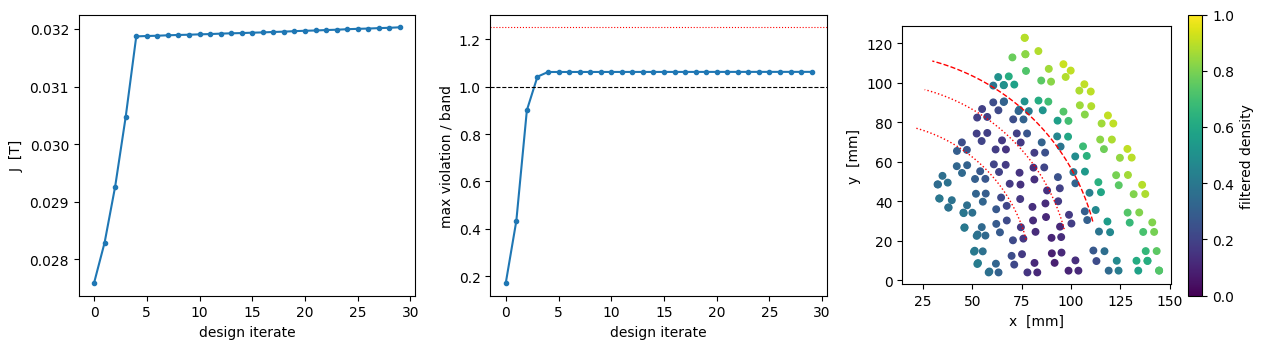

In [3]:
import matplotlib.pyplot as plt
from ngsolve import Integrate, x as X, y as Y

with TaskManager():
    vols = sector.element_volumes
    cx = np.asarray(Integrate(X, mesh, element_wise=True), float) / vols
    cy = np.asarray(Integrate(Y, mesh, element_wise=True), float) / vols
    rho_f = np.clip(filt.apply(result.density), 0.0, 1.0)

fig, axes = plt.subplots(1, 3, figsize=(12.8, 3.6))
it = [h['iteration'] for h in hist]
axes[0].plot(it, [h['objective'] for h in hist], marker='.')
axes[0].set_xlabel('design iterate')
axes[0].set_ylabel('J  [T]')
ratio = [max(np.array(h['violation']) / np.array(h['band'])) for h in hist]
axes[1].plot(it, ratio, marker='.')
axes[1].axhline(1.0, color='k', lw=0.8, ls='--')
axes[1].axhline(1.25, color='r', lw=0.8, ls=':')
axes[1].set_xlabel('design iterate')
axes[1].set_ylabel('max violation / band')
sc = axes[2].scatter(cx * 1e3, cy * 1e3, c=rho_f, s=22, cmap='viridis', vmin=0, vmax=1)
for rr, ls in ((0.115, '--'), (0.08, ':'), (0.10, ':')):
    th = np.linspace(SPAN[0], SPAN[1], 60)
    axes[2].plot(rr * np.cos(th) * 1e3, rr * np.sin(th) * 1e3, color='r', ls=ls, lw=1)
axes[2].set_xlabel('x  [mm]')
axes[2].set_ylabel('y  [mm]')
axes[2].set_aspect('equal')
fig.colorbar(sc, ax=axes[2], label='filtered density')
fig.tight_layout()
plt.show()


In [4]:
from ngsolve import GridFunction, L2, Norm
from ngsolve.webgui import Draw

rho_view = GridFunction(L2(mesh, order=0))
rho_view.vec.FV().NumPy()[:] = rho_f
with TaskManager():
    gfM_view, _ = sector.solve(
        density_to_s(rho_f, CHI_IRON), f_state, tol=1e-10)

mesh_scene = Draw(
    mesh,
    name="isochronous_design_mesh",
    draw_vol=True,
    draw_surf=True,
    width="100%",
    height="420px",
)
field_scene = Draw(
    Norm(gfM_view),
    mesh,
    name="magnetization_magnitude",
    draw_vol=True,
    draw_surf=True,
    autoscale=True,
    width="100%",
    height="500px",
)
field_scene


WebGuiWidget(layout=Layout(height='420px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

Left: strictly monotone constrained ascent.  Middle: violations ride the ACTIVE band edge and stay under the
$1.25\times$band acceptance cap.  Right: converged filtered density (top view, element centroids; dashed arc =
objective radius, dotted arcs = constraint radii).


## 3. Exact-void verification (Stage-3 protocol)

The converged density is thresholded at 0.5 and re-evaluated twice at MATCHED 0/1 representation: on the parent
mesh with the ersatz void ($\chi_{\min}=10^{-6}$), and on a NEW iron-only mesh with the void REMOVED
(`iron_only_mesh` -- exact-void gold standard at the design's own discretization).  The band quantifies the
ersatz error honestly; the separate continuous-vs-threshold gap is the gray-design diagnostic.


In [5]:
with TaskManager():
    ver = verify_design_iron_only(sector, result.density, state_builder,
                                  [objective_builder] + con_builders,
                                  chi_iron=CHI_IRON, density_filter=filt,
                                  gram_kwargs=dict(eps=1e-7))
J_bin, J_iron = ver.values_embedded[0], ver.values_iron_only[0]
gap = (hist[-1]['objective'] - J_bin) / abs(J_bin)
summary['verification'] = dict(
    n_iron=int(ver.keep.sum()), J_embedded_bin=float(J_bin), J_iron_only=float(J_iron),
    ersatz_band=float(ver.bands[0]), gray_gap=float(gap),
    constraint_bands=[float(b) for b in ver.bands[1:]])
print(f"iron elements after threshold: {int(ver.keep.sum())}/{sector.n_el}")
print(f"J embedded 0/1      = {J_bin:+.6e}")
print(f"J iron-only exact   = {J_iron:+.6e}")
print(f"ERSATZ band         = {ver.bands[0]*100:+.2f}%   (constraints: "
      + ', '.join(f'{b*100:+.2f}%' for b in ver.bands[1:]) + ')')
print(f"gray-design gap (continuous vs 0/1) = {gap*100:+.1f}%  ->"
      " threshold-ready designs need penalty/projection continuation")
summary


iron elements after threshold: 66/194
J embedded 0/1      = +7.829799e-01
J iron-only exact   = +7.776454e-01
ERSATZ band         = +0.69%   (constraints: -4.91%, -47.09%)
gray-design gap (continuous vs 0/1) = -95.9%  -> threshold-ready designs need penalty/projection continuation


{'adjoint_gate': {'ne': 270,
  'ndof': 1977,
  'directional_fd_rel': 1.7836724836686516e-07,
  'reciprocity_rel': 1.0987465601726383e-10},
 'design_loop': {'ne': 194,
  'iterations': 30,
  'solves': 49,
  'J_first': 0.02758902119229375,
  'J_last': 0.03202970203227957,
  'gain': 0.16095825977422518,
  'viol_over_band_max': 1.0620757431165846,
  't_iter_median_s': 0.11488845001440495,
  't_loop_s': 3.7822066000080667},
 'verification': {'n_iron': 66,
  'J_embedded_bin': 0.7829798842374768,
  'J_iron_only': 0.7776454036123537,
  'ersatz_band': 0.006859785450210499,
  'gray_gap': -0.9590925607706097,
  'constraint_bands': [-0.049053660936887546, -0.47089787539375605]}}

## 4. Scope and known limits

* All numbers above are VERIFICATION-SCALE (hundreds of elements); study-scale runs and benchmark-grade
  timings belong on the quiet compute hosts per the repository benchmark policy.
* The surrogate design above is deliberately GRAY (filter radius near the element size, no projection): the
  protocol exposes it (the -96 % class gap).  `density_to_s(..., penalty=3)` moves designs toward 0/1; the
  full penalty/projection continuation is part of the real isochronous design study.
* The iron-only extraction keeps the design's STAIRCASE boundary; staircase boundaries do not converge to the
  smooth body (hemisphere $\langle M_z\rangle$: +4.6/+7.7 % vs the smooth-meshed hemisphere at maxh .35/.22).
  Manufacturing-shape numbers come from the shape route on a smoothed body-fitted remesh.
* Full stage gates and rejected schemes: `TOPOLOGY_OPTIMIZATION_ISOCHRONOUS.md`; golden-band lane:
  `validation_test/isochronous_topopt/`.
